In [45]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from scipy import linalg

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


train: (1530, 16, 16, 1) test: (270, 16, 16, 1)


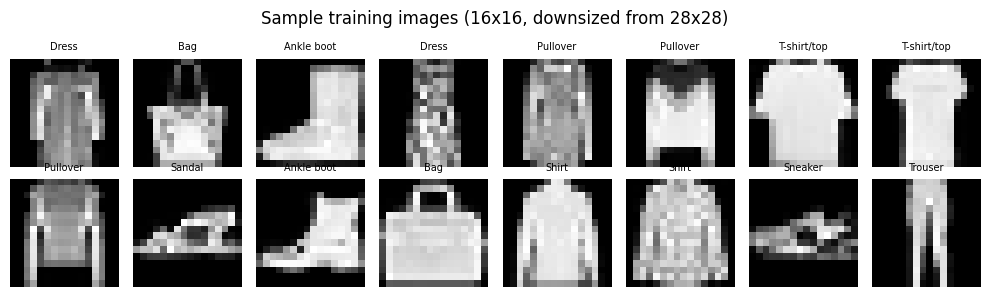

In [46]:
from tensorflow.keras.datasets import fashion_mnist

FASHION_MNIST_CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

def load_data():
    (x_all, y_all), (_, _) = fashion_mnist.load_data()
    images = x_all.astype("float32") / 255.0                  # [0, 1], shape (N, 28, 28)
    labels = y_all.astype("int32")
    images = images[..., None]                                 # (N, 28, 28, 1)

    # Subsample for fast CPU training, then downsize to 16x16 to match the rest
    # of the notebook's architecture (kept resolution-agnostic elsewhere).
    rng = np.random.RandomState(42)
    idx = rng.choice(len(images), size=1800, replace=False)
    images, labels = images[idx], labels[idx]

    images_16 = tf.image.resize(images, [16, 16], method="bilinear").numpy()
    images_16 = np.clip(images_16, 0.0, 1.0)

    idx = rng.permutation(len(images_16))
    images_16, labels = images_16[idx], labels[idx]
    n_train = int(0.85 * len(images_16))
    x_train, x_test = images_16[:n_train], images_16[n_train:]
    y_train, y_test = labels[:n_train], labels[n_train:]
    return (x_train, y_train), (x_test, y_test)

(x_train, y_train), (x_test, y_test) = load_data()
print("train:", x_train.shape, "test:", x_test.shape)

fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i, ..., 0], cmap="gray")
    ax.set_title(FASHION_MNIST_CLASS_NAMES[y_train[i]], fontsize=7)
    ax.axis("off")
fig.suptitle("Sample training images (16x16, downsized from 28x28)")
plt.tight_layout()
plt.show()


In [47]:
LATENT_DIM = 16

class Encoder(keras.Model):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv1 = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")
        self.conv2 = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")
        self.flatten = layers.Flatten()
        self.dense_mu = layers.Dense(latent_dim)
        self.dense_logvar = layers.Dense(latent_dim)

    def call(self, x):
        h = self.conv1(x)          # 16x16 -> 8x8
        h = self.conv2(h)          # 8x8 -> 4x4
        h = self.flatten(h)
        return self.dense_mu(h), self.dense_logvar(h)

class Decoder(keras.Model):
    def __init__(self, latent_dim):
        super().__init__()
        self.dense = layers.Dense(4 * 4 * 64, activation="relu")
        self.reshape = layers.Reshape((4, 4, 64))
        self.deconv1 = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")
        self.deconv2 = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")
        self.out = layers.Conv2D(1, 3, padding="same", activation="sigmoid")

    def call(self, z):
        h = self.dense(z)
        h = self.reshape(h)
        h = self.deconv1(h)        # 4x4 -> 8x8
        h = self.deconv2(h)        # 8x8 -> 16x16
        return self.out(h)

class VAE(keras.Model):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        eps = tf.random.normal(shape=tf.shape(mu))
        return mu + tf.exp(0.5 * logvar) * eps

    def call(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

def vae_loss(x, x_recon, mu, logvar):
    recon = tf.reduce_sum(keras.losses.binary_crossentropy(x, x_recon), axis=[1, 2])
    kl = -0.5 * tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1)
    return tf.reduce_mean(recon + kl), tf.reduce_mean(recon), tf.reduce_mean(kl)

vae = VAE(LATENT_DIM)
print(vae)


<VAE name=vae_3, built=False>


In [48]:
VAE_EPOCHS = 100
vae_opt = keras.optimizers.Adam(1e-3)
train_ds = tf.data.Dataset.from_tensor_slices(x_train).shuffle(2000).batch(64)

vae_history = {"loss": [], "recon": [], "kl": []}
for epoch in range(VAE_EPOCHS):
    ep_loss, ep_recon, ep_kl = [], [], []
    for batch in train_ds:
        with tf.GradientTape() as tape:
            x_recon, mu, logvar = vae(batch)
            loss, recon, kl = vae_loss(batch, x_recon, mu, logvar)
        grads = tape.gradient(loss, vae.trainable_variables)
        vae_opt.apply_gradients(zip(grads, vae.trainable_variables))
        ep_loss.append(loss.numpy()); ep_recon.append(recon.numpy()); ep_kl.append(kl.numpy())
    vae_history["loss"].append(np.mean(ep_loss))
    vae_history["recon"].append(np.mean(ep_recon))
    vae_history["kl"].append(np.mean(ep_kl))
    if epoch % 10 == 0 or epoch == VAE_EPOCHS - 1:
        print(f"epoch {epoch:3d}  loss={vae_history['loss'][-1]:.2f}  "
              f"recon={vae_history['recon'][-1]:.2f}  kl={vae_history['kl'][-1]:.2f}")


epoch   0  loss=166.41  recon=166.38  kl=0.03
epoch  10  loss=96.78  recon=89.29  kl=7.49
epoch  20  loss=93.01  recon=85.95  kl=7.05
epoch  30  loss=91.74  recon=84.78  kl=6.96
epoch  40  loss=91.15  recon=84.08  kl=7.07
epoch  50  loss=90.61  recon=83.48  kl=7.13
epoch  60  loss=90.26  recon=83.03  kl=7.22
epoch  70  loss=90.17  recon=83.06  kl=7.12
epoch  80  loss=89.89  recon=82.59  kl=7.30
epoch  90  loss=89.66  recon=82.43  kl=7.23
epoch  99  loss=89.62  recon=82.28  kl=7.35


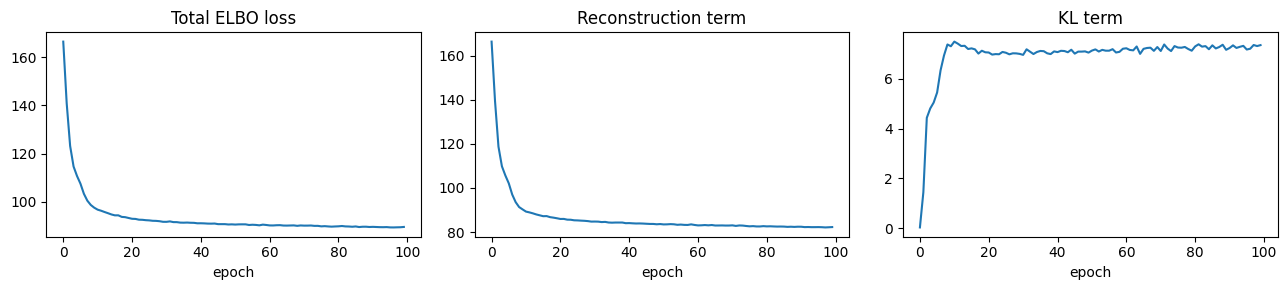

In [49]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3))
ax[0].plot(vae_history["loss"]); ax[0].set_title("Total ELBO loss"); ax[0].set_xlabel("epoch")
ax[1].plot(vae_history["recon"]); ax[1].set_title("Reconstruction term"); ax[1].set_xlabel("epoch")
ax[2].plot(vae_history["kl"]); ax[2].set_title("KL term"); ax[2].set_xlabel("epoch")
plt.tight_layout(); plt.show()


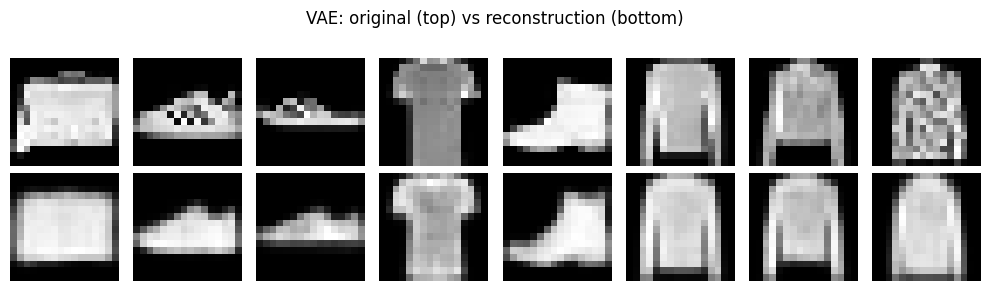

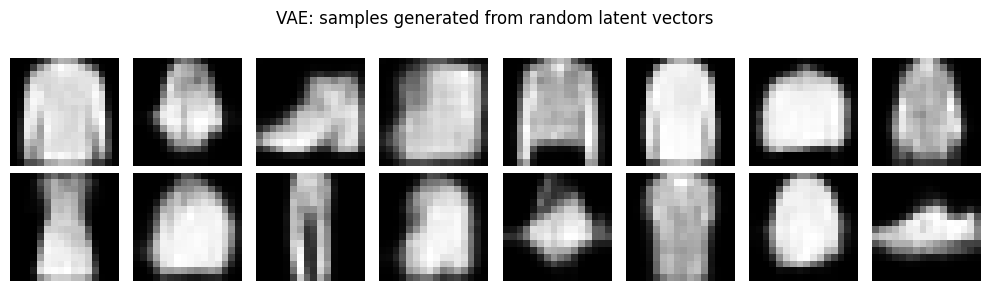

In [50]:
# Reconstructions: original vs. VAE round-trip
x_recon_test, _, _ = vae(x_test[:8])
fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for i in range(8):
    axes[0, i].imshow(x_test[i, ..., 0], cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(x_recon_test[i, ..., 0].numpy(), cmap="gray"); axes[1, i].axis("off")
axes[0, 0].set_ylabel("original"); axes[1, 0].set_ylabel("reconstructed")
fig.suptitle("VAE: original (top) vs reconstruction (bottom)")
plt.tight_layout(); plt.show()

# Pure generation: sample z ~ N(0, I) and decode
z_sample = tf.random.normal((16, LATENT_DIM))
vae_generated_preview = vae.decoder(z_sample).numpy()
fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(vae_generated_preview[i, ..., 0], cmap="gray"); ax.axis("off")
fig.suptitle("VAE: samples generated from random latent vectors")
plt.tight_layout(); plt.show()


In [51]:
T = 200
beta_start, beta_end = 1e-4, 0.02
betas = np.linspace(beta_start, beta_end, T).astype("float32")
alphas = 1.0 - betas
alpha_bars = np.cumprod(alphas).astype("float32")

betas_tf = tf.constant(betas)
alphas_tf = tf.constant(alphas)
ab_tf = tf.constant(alpha_bars)

def sinusoidal_embedding(t, dim=64):
    t = tf.cast(t, tf.float32)[:, None]
    half = dim // 2
    freqs = tf.exp(-np.log(10000.0) * tf.range(half, dtype=tf.float32) / half)
    args = t * freqs[None, :]
    return tf.concat([tf.sin(args), tf.cos(args)], axis=-1)

class TimeMLP(layers.Layer):
    def __init__(self, dim):
        super().__init__()
        self.d1 = layers.Dense(dim, activation="swish")
        self.d2 = layers.Dense(dim)

    def call(self, t_emb):
        return self.d2(self.d1(t_emb))

class ResBlock(layers.Layer):
    """Conv block with GroupNorm + swish + a time-embedding bias injected mid-block."""
    def __init__(self, channels):
        super().__init__()
        self.channels = channels
        self.conv1 = layers.Conv2D(channels, 3, padding="same")
        self.conv2 = layers.Conv2D(channels, 3, padding="same")
        self.time_proj = layers.Dense(channels)
        self.act = layers.Activation("swish")
        self.norm1 = layers.GroupNormalization(groups=8)
        self.norm2 = layers.GroupNormalization(groups=8)
        self.skip = None

    def build(self, input_shape):
        if input_shape[-1] != self.channels:
            self.skip = layers.Conv2D(self.channels, 1, padding="same")

    def call(self, x, t_emb):
        h = self.act(self.norm1(x))
        h = self.conv1(h)
        h = h + self.time_proj(t_emb)[:, None, None, :]
        h = self.act(self.norm2(h))
        h = self.conv2(h)
        skip = x if self.skip is None else self.skip(x)
        return h + skip

class SimpleUNet(keras.Model):
    """Tiny U-Net: one down/up level is enough for 16x16 images."""
    def __init__(self, base_ch=48, time_dim=128):
        super().__init__()
        self.time_dim = time_dim
        self.time_mlp = TimeMLP(time_dim)
        self.in_conv = layers.Conv2D(base_ch, 3, padding="same")
        self.down1 = ResBlock(base_ch)
        self.pool = layers.AveragePooling2D(2)
        self.down2 = ResBlock(base_ch * 2)
        self.mid = ResBlock(base_ch * 2)
        self.up = layers.UpSampling2D(2)
        self.up_conv = layers.Conv2D(base_ch * 2, 3, padding="same")
        self.merge_conv = layers.Conv2D(base_ch, 1, padding="same")
        self.up1 = ResBlock(base_ch)
        self.out_norm = layers.GroupNormalization(groups=8)
        self.out_conv = layers.Conv2D(1, 3, padding="same")

    def call(self, x, t):
        t_emb = self.time_mlp(sinusoidal_embedding(t, self.time_dim))
        h = self.in_conv(x)
        h1 = self.down1(h, t_emb)          # 16x16, base_ch
        h2 = self.pool(h1)                  # 8x8
        h2 = self.down2(h2, t_emb)          # 8x8, base_ch*2
        h2 = self.mid(h2, t_emb)
        h_up = self.up_conv(self.up(h2))    # 16x16, base_ch*2
        h_cat = self.merge_conv(tf.concat([h_up, h1], axis=-1))
        out = self.up1(h_cat, t_emb)
        out = tf.nn.silu(self.out_norm(out))
        return self.out_conv(out)

ddpm_model = SimpleUNet()
_ = ddpm_model(tf.zeros((1, 16, 16, 1)), tf.zeros((1,), dtype=tf.int32))  # build
print(ddpm_model.summary())


Model: "simple_u_net_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_mlp_3 (TimeMLP)            │ ?                      │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (1, 16, 16, 48)        │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_12 (ResBlock)         │ ?                      │        47,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ ?                      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_13 (ResBlock)         │ ?                      │       141,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_14 (ResBlock)         │ ?                      │       178,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (1, 16, 16, 96)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (1, 16, 16, 96)        │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (1, 16, 16, 48)        │         6,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_15 (ResBlock)         │ ?                      │        47,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ group_normalization_35          │ (1, 16, 16, 48)        │            96 │
│ (GroupNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_68 (Conv2D)              │ (1, 16, 16, 1)         │           433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 540,769 (2.06 MB)

 Trainable params: 540,769 (2.06 MB)

 Non-trainable params: 0 (0.00 B)

None


In [52]:
DDPM_EPOCHS = 100
ddpm_opt = keras.optimizers.Adam(1e-3)
ddpm_ds = tf.data.Dataset.from_tensor_slices(x_train).shuffle(2000).batch(64)

@tf.function
def ddpm_train_step(x0):
    bsz = tf.shape(x0)[0]
    t = tf.random.uniform([bsz], 0, T, dtype=tf.int32)
    ab_t = tf.gather(ab_tf, t)[:, None, None, None]
    noise = tf.random.normal(tf.shape(x0))
    x_t = tf.sqrt(ab_t) * x0 + tf.sqrt(1 - ab_t) * noise
    with tf.GradientTape() as tape:
        pred_noise = ddpm_model(x_t, t)
        loss = tf.reduce_mean(tf.square(noise - pred_noise))
    grads = tape.gradient(loss, ddpm_model.trainable_variables)
    ddpm_opt.apply_gradients(zip(grads, ddpm_model.trainable_variables))
    return loss

ddpm_history = []
for epoch in range(DDPM_EPOCHS):
    ep_losses = []
    for batch in ddpm_ds:
        ep_losses.append(ddpm_train_step(batch).numpy())
    ddpm_history.append(np.mean(ep_losses))
    if epoch % 10 == 0 or epoch == DDPM_EPOCHS - 1:
        print(f"epoch {epoch:3d}  noise-MSE={ddpm_history[-1]:.4f}")


epoch   0  noise-MSE=0.6592
epoch  10  noise-MSE=0.1110
epoch  20  noise-MSE=0.0943
epoch  30  noise-MSE=0.0849
epoch  40  noise-MSE=0.0840
epoch  50  noise-MSE=0.0887
epoch  60  noise-MSE=0.0803
epoch  70  noise-MSE=0.0829
epoch  80  noise-MSE=0.0781
epoch  90  noise-MSE=0.0745
epoch  99  noise-MSE=0.0763


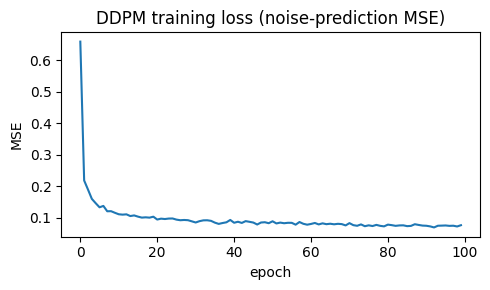

In [53]:
plt.figure(figsize=(5, 3))
plt.plot(ddpm_history)
plt.title("DDPM training loss (noise-prediction MSE)")
plt.xlabel("epoch"); plt.ylabel("MSE")
plt.tight_layout(); plt.show()


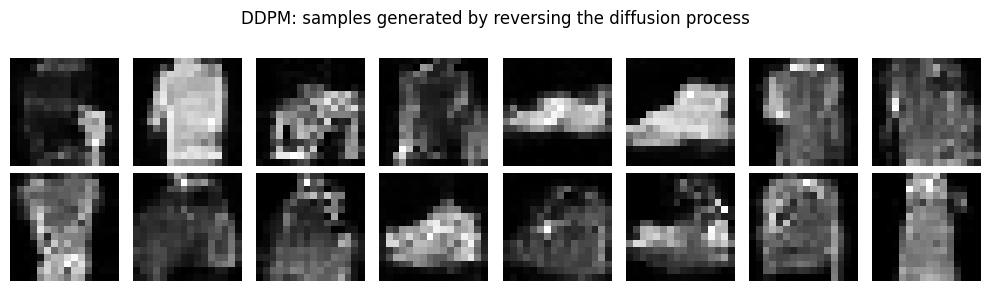

In [54]:
@tf.function
def p_sample_step(x, t_val, add_noise):
    bsz = tf.shape(x)[0]
    t = tf.fill([bsz], t_val)
    beta_t = tf.gather(betas_tf, t)[:, None, None, None]
    alpha_t = tf.gather(alphas_tf, t)[:, None, None, None]
    ab_t = tf.gather(ab_tf, t)[:, None, None, None]
    eps_theta = ddpm_model(x, t)
    mean = (1.0 / tf.sqrt(alpha_t)) * (x - (beta_t / tf.sqrt(1 - ab_t)) * eps_theta)
    if add_noise:
        noise = tf.random.normal(tf.shape(x))
        sigma_t = tf.sqrt(beta_t)
        return mean + sigma_t * noise
    return mean

def ddpm_sample(n_images):
    x = tf.random.normal((n_images, 16, 16, 1))
    for t in reversed(range(T)):
        x = p_sample_step(x, tf.constant(t, dtype=tf.int32), t > 0)
    return tf.clip_by_value(x, 0.0, 1.0).numpy()

ddpm_preview = ddpm_sample(16)
fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(ddpm_preview[i, ..., 0], cmap="gray"); ax.axis("off")
fig.suptitle("DDPM: samples generated by reversing the diffusion process")
plt.tight_layout(); plt.show()


In [55]:
def build_classifier():
    inp = layers.Input((16, 16, 1))
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inp)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    feat = layers.Dense(64, activation="relu", name="features")(x)
    out = layers.Dense(10, activation="softmax")(feat)
    clf = keras.Model(inp, out)
    feat_extractor = keras.Model(inp, feat)
    return clf, feat_extractor

clf, feat_extractor = build_classifier()
clf.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
clf.fit(x_train, y_train, epochs=15, batch_size=64, validation_data=(x_test, y_test), verbose=2)


Epoch 1/15
24/24 - 5s - 197ms/step - accuracy: 0.4562 - loss: 1.9125 - val_accuracy: 0.5481 - val_loss: 1.3129
Epoch 2/15
24/24 - 0s - 8ms/step - accuracy: 0.6320 - loss: 1.0013 - val_accuracy: 0.6444 - val_loss: 0.8600
Epoch 3/15
24/24 - 0s - 7ms/step - accuracy: 0.7098 - loss: 0.7807 - val_accuracy: 0.7333 - val_loss: 0.7127
Epoch 4/15
24/24 - 0s - 7ms/step - accuracy: 0.7399 - loss: 0.7124 - val_accuracy: 0.7556 - val_loss: 0.6266
Epoch 5/15
24/24 - 0s - 8ms/step - accuracy: 0.7627 - loss: 0.6499 - val_accuracy: 0.7519 - val_loss: 0.6041
Epoch 6/15
24/24 - 0s - 7ms/step - accuracy: 0.7797 - loss: 0.6075 - val_accuracy: 0.7704 - val_loss: 0.5747
Epoch 7/15
24/24 - 0s - 7ms/step - accuracy: 0.7856 - loss: 0.5765 - val_accuracy: 0.7630 - val_loss: 0.5595
Epoch 8/15
24/24 - 0s - 7ms/step - accuracy: 0.7967 - loss: 0.5483 - val_accuracy: 0.7667 - val_loss: 0.5440
Epoch 9/15
24/24 - 0s - 7ms/step - accuracy: 0.8046 - loss: 0.5239 - val_accuracy: 0.7741 - val_loss: 0.5314
Epoch 10/15
24/24

Epoch 8/15


24/24 - 0s - 11ms/step - accuracy: 0.9692 - loss: 0.1006 - val_accuracy: 0.9556 - val_loss: 0.1485


Epoch 9/15


24/24 - 0s - 14ms/step - accuracy: 0.9738 - loss: 0.0854 - val_accuracy: 0.9593 - val_loss: 0.1322


...

24/24 - 0s - 13ms/step - accuracy: 0.9882 - loss: 0.0476 - val_accuracy: 0.9704 - val_loss: 0.1024


Epoch 14/15


24/24 - 0s - 12ms/step - accuracy: 0.9908 - loss: 0.0411 - val_accuracy: 0.9741 - val_loss: 0.0976


Epoch 15/15


24/24 - 0s - 13ms/step - accuracy: 0.9921 - loss: 0.0359 - val_accuracy: 0.9704 - val_loss: 0.0941


In [56]:
def compute_fid(feat_real, feat_fake):
    mu1, mu2 = feat_real.mean(axis=0), feat_fake.mean(axis=0)
    sigma1 = np.cov(feat_real, rowvar=False)
    sigma2 = np.cov(feat_fake, rowvar=False)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean))

def compute_inception_score(preds, eps=1e-10):
    py = preds.mean(axis=0, keepdims=True)
    kl = (preds * (np.log(preds + eps) - np.log(py + eps))).sum(axis=1)
    return float(np.exp(kl.mean()))

N_EVAL = len(x_test)  # generate as many fake images as we have real test images

# --- VAE samples for evaluation ---
z_eval = tf.random.normal((N_EVAL, LATENT_DIM))
vae_eval_images = vae.decoder(z_eval).numpy()

# --- DDPM samples for evaluation ---
ddpm_eval_images = ddpm_sample(N_EVAL)

# --- Real reference features/predictions ---
feat_real = feat_extractor.predict(x_test, verbose=0)
preds_real = clf.predict(x_test, verbose=0)

feat_vae = feat_extractor.predict(vae_eval_images, verbose=0)
preds_vae = clf.predict(vae_eval_images, verbose=0)

feat_ddpm = feat_extractor.predict(ddpm_eval_images, verbose=0)
preds_ddpm = clf.predict(ddpm_eval_images, verbose=0)

fid_vae = compute_fid(feat_real, feat_vae)
fid_ddpm = compute_fid(feat_real, feat_ddpm)
is_vae = compute_inception_score(preds_vae)
is_ddpm = compute_inception_score(preds_ddpm)
is_real = compute_inception_score(preds_real)

print(f"{'Model':<10}{'FID (lower=better)':<22}{'Inception Score (higher=better)'}")
print(f"{'Real test':<10}{'--':<22}{is_real:.3f}")
print(f"{'VAE':<10}{fid_vae:<22.3f}{is_vae:.3f}")
print(f"{'DDPM':<10}{fid_ddpm:<22.3f}{is_ddpm:.3f}")


Model     FID (lower=better)    Inception Score (higher=better)
Real test --                    6.070
VAE       34.968                3.878
DDPM      69.549                3.251


/tmp/ipykernel_58/1370326960.py:6: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
/tmp/ipykernel_58/1370326960.py:6: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)


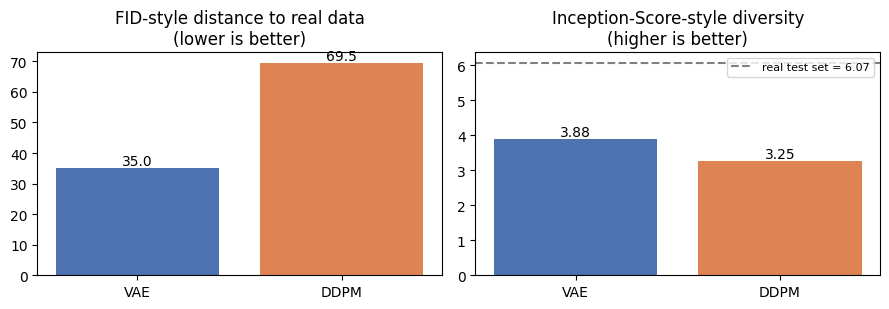

In [57]:
labels_metric = ["VAE", "DDPM"]
fid_vals = [fid_vae, fid_ddpm]
is_vals = [is_vae, is_ddpm]

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
bars0 = ax[0].bar(labels_metric, fid_vals, color=["#4C72B0", "#DD8452"])
ax[0].set_title("FID-style distance to real data\n(lower is better)")
bars1 = ax[1].bar(labels_metric, is_vals, color=["#4C72B0", "#DD8452"])
ax[1].axhline(is_real, color="gray", linestyle="--", label=f"real test set = {is_real:.2f}")
ax[1].set_title("Inception-Score-style diversity\n(higher is better)")
ax[1].legend(fontsize=8)
for b in bars0: ax[0].annotate(f"{b.get_height():.1f}", (b.get_x()+b.get_width()/2, b.get_height()), ha="center", va="bottom")
for b in bars1: ax[1].annotate(f"{b.get_height():.2f}", (b.get_x()+b.get_width()/2, b.get_height()), ha="center", va="bottom")
plt.tight_layout(); plt.show()


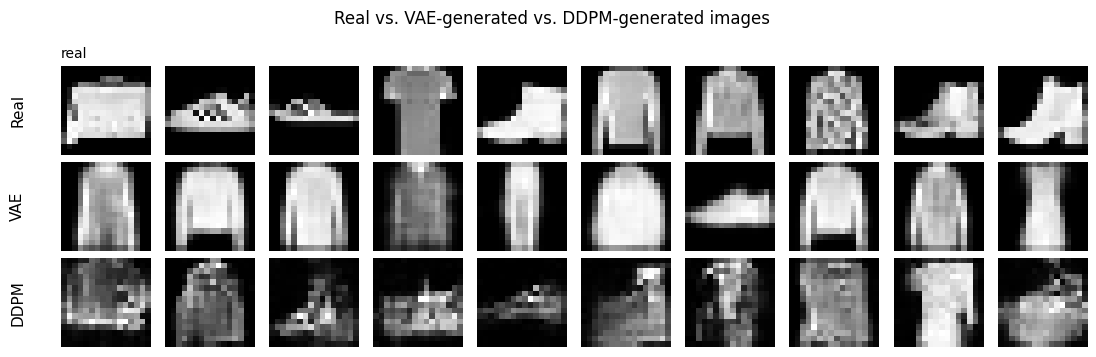

In [58]:
n_show = 10
fig, axes = plt.subplots(3, n_show, figsize=(1.1 * n_show, 3.6))
for i in range(n_show):
    axes[0, i].imshow(x_test[i, ..., 0], cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(vae_eval_images[i, ..., 0], cmap="gray"); axes[1, i].axis("off")
    axes[2, i].imshow(ddpm_eval_images[i, ..., 0], cmap="gray"); axes[2, i].axis("off")
axes[0, 0].set_title("real", loc="left", fontsize=10)
for row, name in enumerate(["Real", "VAE", "DDPM"]):
    axes[row, 0].annotate(name, xy=(-0.4, 0.5), xycoords="axes fraction",
                           ha="right", va="center", fontsize=11, rotation=90)
fig.suptitle("Real vs. VAE-generated vs. DDPM-generated images")
plt.tight_layout(); plt.show()
